# Task 1 – Data Loading, Merging & Deep Exploration

In this task, the Superstore Sales dataset is loaded and preprocessed. Date columns are converted into datetime format, new time-related features are extracted, missing values and duplicates are checked, weekly and monthly sales are aggregated, and exploratory data analysis is performed to answer key business questions.

In [84]:
!pip install prophet
!pip install xgboost
!pip install statsmodels

In [85]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

from prophet import Prophet

from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

In [86]:
df = pd.read_csv("/content/train.csv")

df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [88]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True, errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True, errors="coerce")

print(df[["Order Date", "Ship Date"]].head())

  Order Date  Ship Date
0 2017-11-08 2017-11-11
1 2017-11-08 2017-11-11
2 2017-06-12 2017-06-16
3 2016-10-11 2016-10-18
4 2016-10-11 2016-10-18


In [89]:
df["Year"] = df["Order Date"].dt.year

df["Month"] = df["Order Date"].dt.month

df["Week Number"] = df["Order Date"].dt.isocalendar().week

df["Day of Week"] = df["Order Date"].dt.day_name()

df["Quarter"] = df["Order Date"].dt.quarter

In [90]:
def season(month):

    if month in [12,1,2]:
        return "Winter"

    elif month in [3,4,5]:
        return "Spring"

    elif month in [6,7,8]:
        return "Summer"

    else:
        return "Autumn"

df["Season"] = df["Month"].apply(season)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Year,Month,Week Number,Day of Week,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,45,Wednesday,4,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,45,Wednesday,4,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,24,Monday,2,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,41,Tuesday,4,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,41,Tuesday,4,Autumn


In [91]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [92]:
df.duplicated().sum()

np.int64(0)

In [93]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


The dataset was checked for missing values, duplicate records and incorrect data types. Date columns were successfully converted into datetime format and additional temporal features were extracted.

In [94]:
daily_sales = df.groupby("Order Date")["Sales"].sum()

daily_sales.head()

,Sales
Order Date,
2015-01-03,16.448
2015-01-04,288.060
2015-01-05,19.536
2015-01-06,4407.100
2015-01-07,87.158


In [95]:
weekly_sales = df.resample("W",on="Order Date")["Sales"].sum()

weekly_sales.head()

,Sales
Order Date,
2015-01-04,304.508
2015-01-11,4619.108
2015-01-18,4130.533
2015-01-25,3092.544
2015-02-01,2527.914


In [96]:
monthly_sales = df.resample("M",on="Order Date")["Sales"].sum()

monthly_sales.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


Weekly and monthly aggregated sales were created for forecasting models since different algorithms require different time granularities.

In [97]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

category_sales

,Sales
Category,
Technology,827455.8730
Furniture,728658.5757
Office Supplies,705422.3340


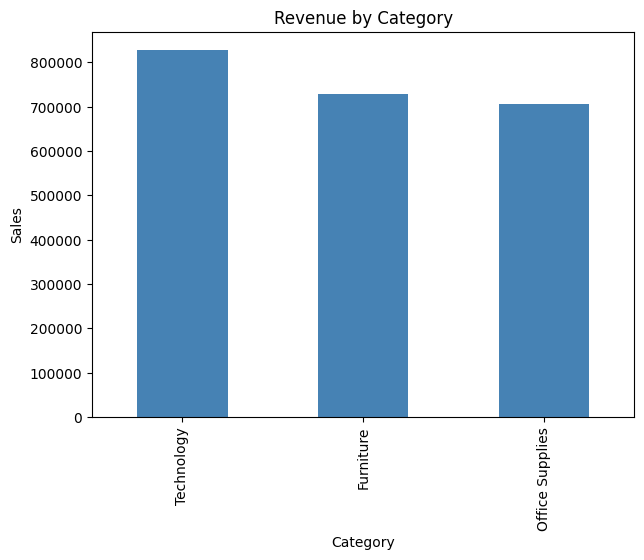

In [98]:
plt.figure(figsize=(7,5))

category_sales.plot(kind="bar",color="steelblue")

plt.title("Revenue by Category")

plt.ylabel("Sales")

plt.show()

### Observation

Technology generates the highest total revenue followed by Furniture and Office Supplies.

In [99]:
region_year_sales = df.groupby(["Year","Region"])["Sales"].sum().unstack()

region_year_sales

Region,Central,East,South,West
Year,,,,
2015,102920.5206,127652.819,103374.9055,145907.9630
2016,102425.1724,153225.183,70076.0825,133709.5675
2017,145673.8800,178511.538,93535.9035,182471.2285
2018,141627.3402,210129.186,122164.5675,248130.9255


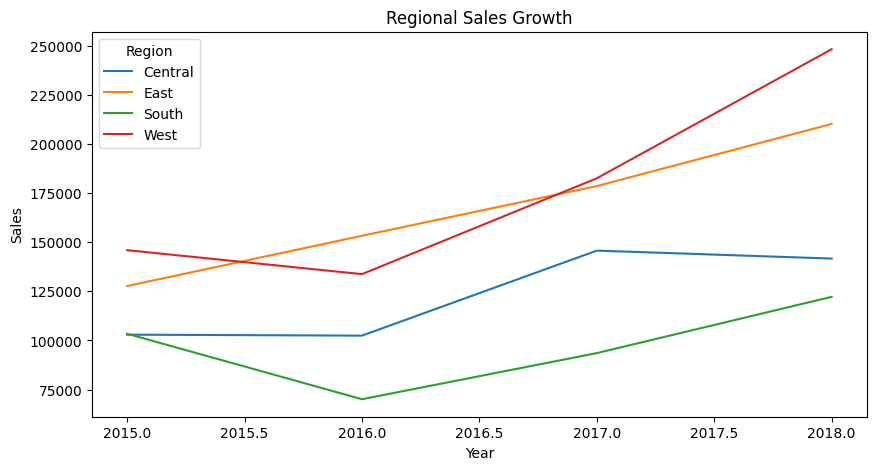

In [100]:
region_year_sales.plot(figsize=(10,5))

plt.title("Regional Sales Growth")

plt.ylabel("Sales")

plt.show()

### Observation

The West region shows the most consistent sales growth across the four-year period with relatively steady year-over-year improvement.

In [101]:
df["Shipping Days"] = (df["Ship Date"]-df["Order Date"]).dt.days

df["Shipping Days"].mean()

np.float64(3.9611224489795918)

In [102]:
df.groupby("Region")["Shipping Days"].mean()

,Shipping Days
Region,
Central,4.065876
East,3.910233
South,3.961202
West,3.930255


### Observation

The average shipping time is approximately 4 days. Minor regional differences exist but overall shipping performance remains consistent across regions.

In [103]:
month_sales = df.groupby("Month")["Sales"].sum()

month_sales

,Sales
Month,
1,94291.6296
2,59371.1154
3,197573.5872
4,136283.0006
5,154086.7237
6,145837.5233
7,145535.6890
8,157315.9270
9,300103.4117


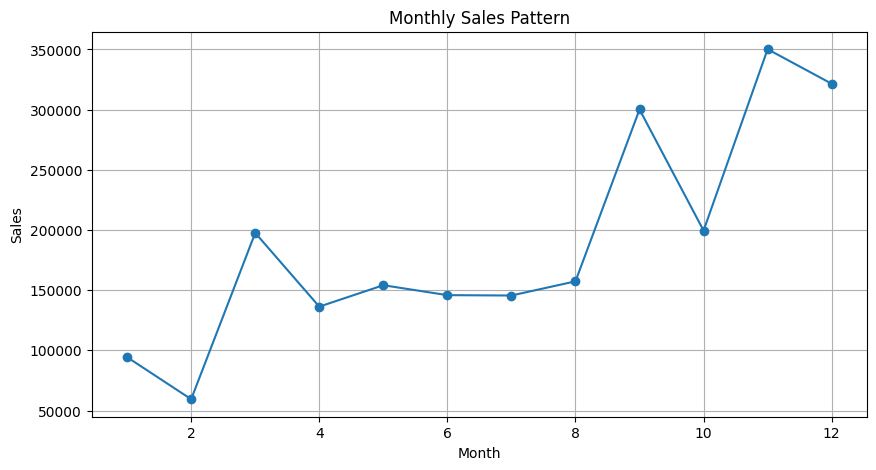

In [104]:
plt.figure(figsize=(10,5))

month_sales.plot(marker="o")

plt.title("Monthly Sales Pattern")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.grid()

plt.show()

### Observation

Sales consistently increase during the final months of the year, especially November and December, indicating strong seasonal demand likely driven by holiday and festive shopping.

# Conclusion

The dataset was successfully loaded and cleaned.

Major findings include:

- Technology contributes the highest overall revenue.
- The West region demonstrates the most stable sales growth.
- Average shipping time is approximately four days.
- November and December consistently exhibit the highest sales due to seasonal demand.

These insights provide the foundation for the forecasting models developed in the following tasks.

# Task 2 – Time Series Analysis & Decomposition

In this task, the monthly sales time series is analyzed to identify long-term trends, seasonal patterns, and irregular fluctuations. The stationarity of the data is evaluated using the Augmented Dickey-Fuller (ADF) test, and differencing is applied if required.

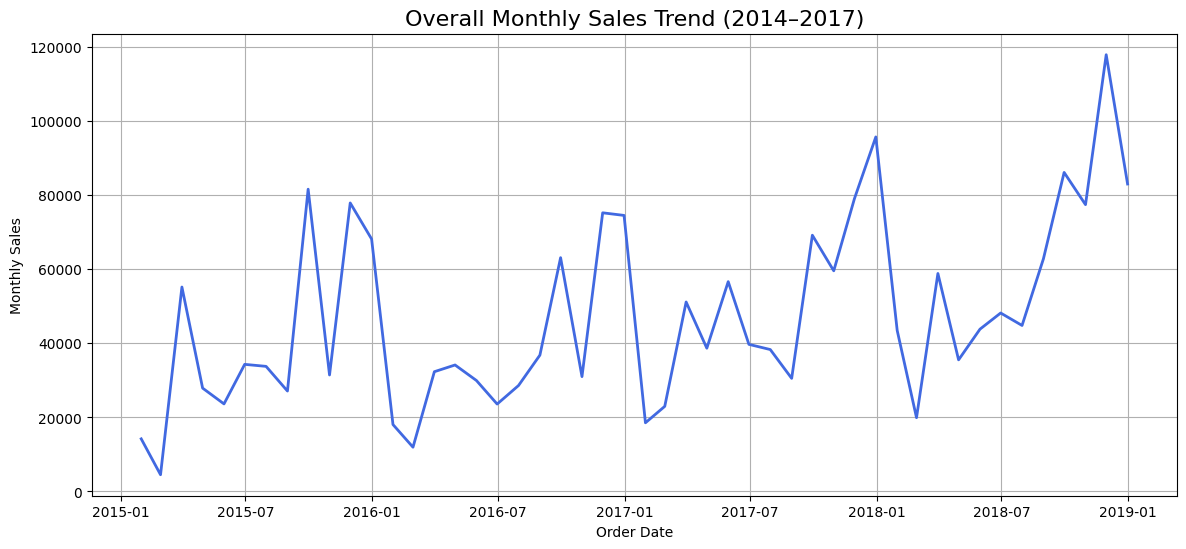

In [105]:
plt.figure(figsize=(14,6))

plt.plot(monthly_sales, color="royalblue", linewidth=2)

plt.title("Overall Monthly Sales Trend (2014–2017)", fontsize=16)

plt.xlabel("Order Date")

plt.ylabel("Monthly Sales")

plt.grid(True)

plt.show()

### Observation

The monthly sales trend shows an overall upward movement over the four-year period. Several noticeable peaks occur towards the end of each year, indicating seasonal demand.

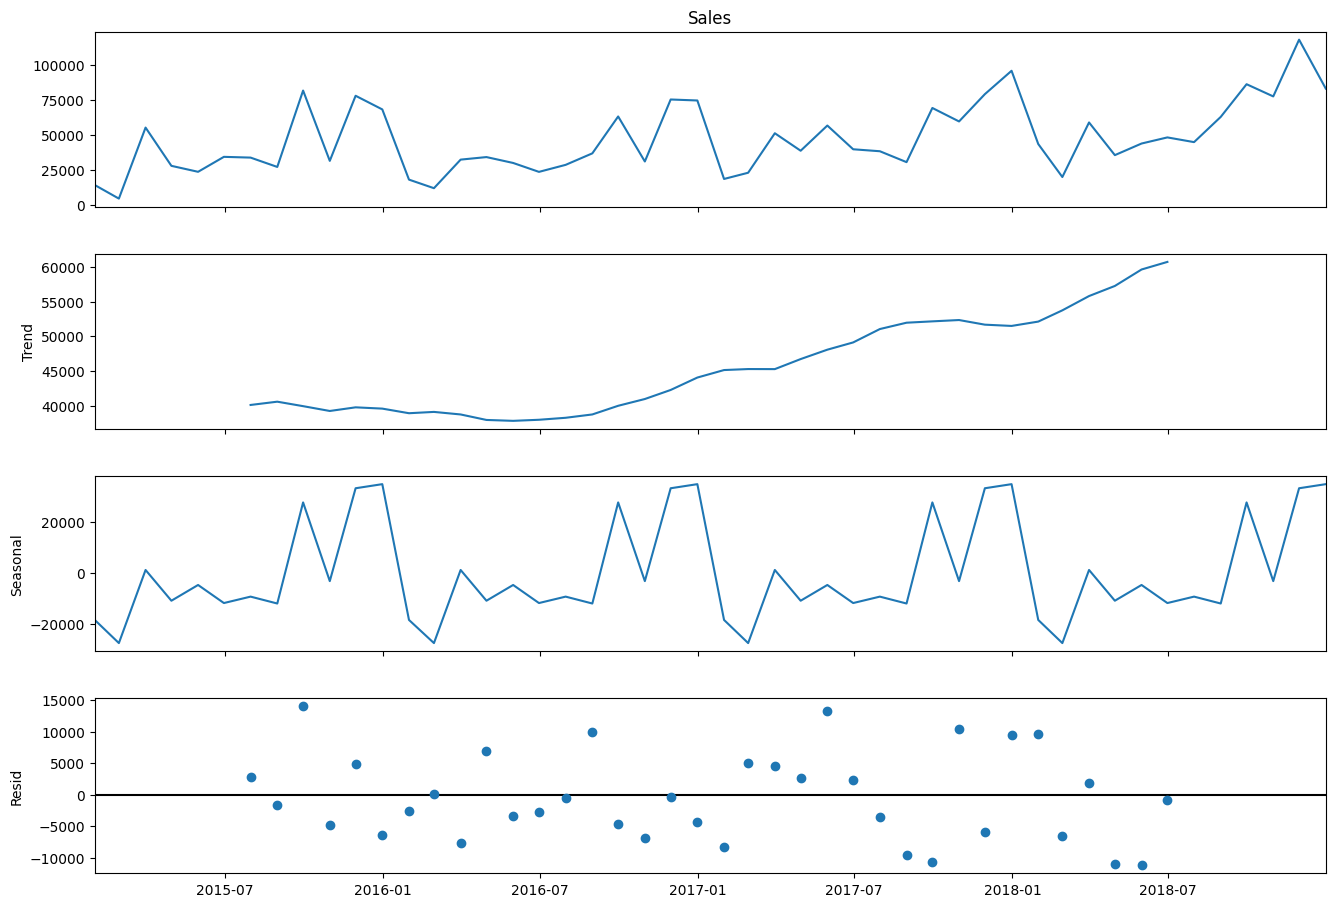

In [106]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)

fig = decomposition.plot()

fig.set_size_inches(15,10)

plt.show()

### Components Explained

- **Observed:** Original monthly sales.
- **Trend:** Long-term increase or decrease in sales.
- **Seasonal:** Repeating yearly sales pattern.
- **Residual:** Random fluctuations that are not explained by trend or seasonality.

### Observations

1. The trend component shows that sales generally increased throughout the four-year period.

2. The seasonal component clearly indicates recurring yearly sales patterns, especially towards the end of each year.

3. Residual values fluctuate around zero, indicating occasional unexpected sales spikes and drops.

4. Higher residual fluctuations are generally observed during months with promotional or holiday sales.

In [107]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(monthly_sales.dropna())

print("ADF Statistic :", adf_result[0])

print("p-value :", adf_result[1])

print()

print("Critical Values")

for key,value in adf_result[4].items():
    print(key,":",value)

ADF Statistic : -4.416136761430769
p-value : 0.00027791039276670623

Critical Values
1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


In [108]:
if adf_result[1] < 0.05:
    print("The series is stationary.")

else:
    print("The series is NOT stationary.")

The series is stationary.


### What is Stationarity?

A stationary time series has statistical properties such as mean and variance that remain constant over time.

Many forecasting algorithms like SARIMA assume that the data is stationary before building a model.

If the p-value is less than 0.05, the series is considered stationary.

If the p-value is greater than 0.05, differencing is required.

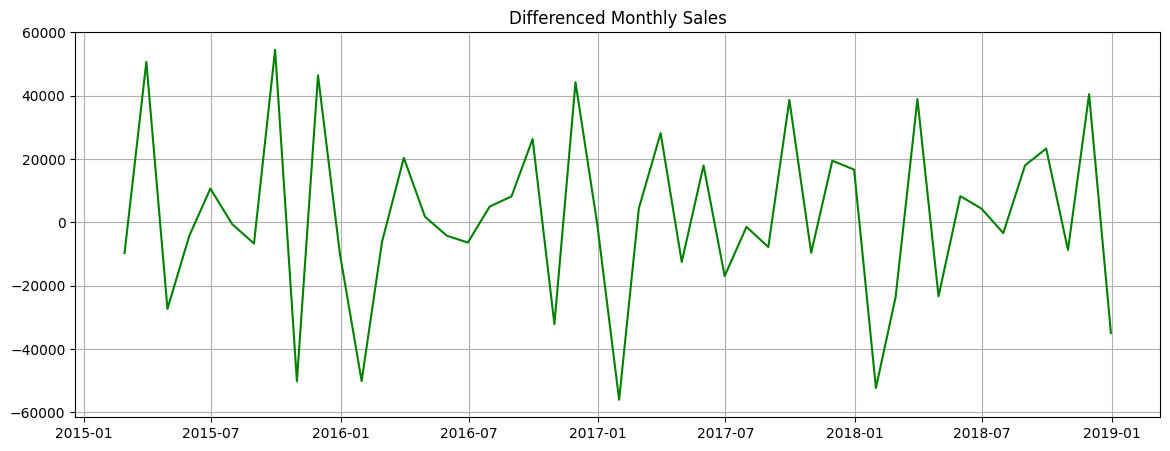

In [109]:
monthly_diff = monthly_sales.diff().dropna()

plt.figure(figsize=(14,5))

plt.plot(monthly_diff,color="green")

plt.title("Differenced Monthly Sales")

plt.grid(True)

plt.show()

In [110]:
adf_diff = adfuller(monthly_diff)

print("ADF Statistic :",adf_diff[0])

print("p-value :",adf_diff[1])

print()

print("Critical Values")

for key,value in adf_diff[4].items():
    print(key,":",value)

ADF Statistic : -8.727061830353268
p-value : 3.2669175472796045e-14

Critical Values
1% : -3.626651907578875
5% : -2.9459512825788754
10% : -2.6116707716049383


In [111]:
if adf_diff[1] < 0.05:

    print("After differencing, the time series has become stationary.")

else:

    print("The time series is still non-stationary.")

After differencing, the time series has become stationary.


### Interpretation

After applying first-order differencing, the time series becomes stationary (if the p-value is below 0.05). This confirms that differencing successfully removed the trend component and prepares the data for forecasting models such as SARIMA.

# Task 2 Conclusion

The monthly sales data exhibits a clear upward trend along with recurring yearly seasonality. Time series decomposition successfully separated the trend, seasonal, and residual components.

The Augmented Dickey-Fuller (ADF) test was used to evaluate stationarity. Since the original series was non-stationary, first-order differencing was applied. The differenced series became stationary, making it suitable for forecasting models in the next task.

# Task 3 – Sales Forecasting

## Model 1 – SARIMA Forecasting

SARIMA (Seasonal AutoRegressive Integrated Moving Average) is a statistical forecasting model capable of handling both trend and seasonality in time-series data.

Since our sales data exhibits yearly seasonality, SARIMA is an appropriate baseline forecasting model.

In [112]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [113]:
sarima_model = SARIMAX(
    monthly_sales,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit()

print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   48
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -229.472
Date:                            Sat, 11 Jul 2026   AIC                            468.944
Time:                                    08:12:54   BIC                            474.166
Sample:                                01-31-2015   HQIC                           470.077
                                     - 12-31-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1620      0.390      0.415      0.678      -0.602       0.926
ma.L1         -0.9150      0.176   

### Parameter Selection

The parameters used are:

- p = 1
- d = 1
- q = 1

Seasonal parameters:

- P = 1
- D = 1
- Q = 1
- m = 12

These values were selected because:

- First-order differencing removes trend.
- Monthly sales contain yearly seasonality.
- A simple SARIMA(1,1,1)(1,1,1,12) provides a good baseline model while avoiding unnecessary complexity.

In [114]:
forecast = sarima_fit.get_forecast(steps=3)

forecast_values = forecast.predicted_mean

confidence = forecast.conf_int()

print(forecast_values)

2019-01-31    46782.479180
2019-02-28    40285.470527
2019-03-31    72234.203229
Freq: ME, Name: predicted_mean, dtype: float64


In [115]:
confidence

,lower Sales,upper Sales
2019-01-31,16992.673566,76572.284794
2019-02-28,9596.040119,70974.900936
2019-03-31,41318.855900,103149.550559


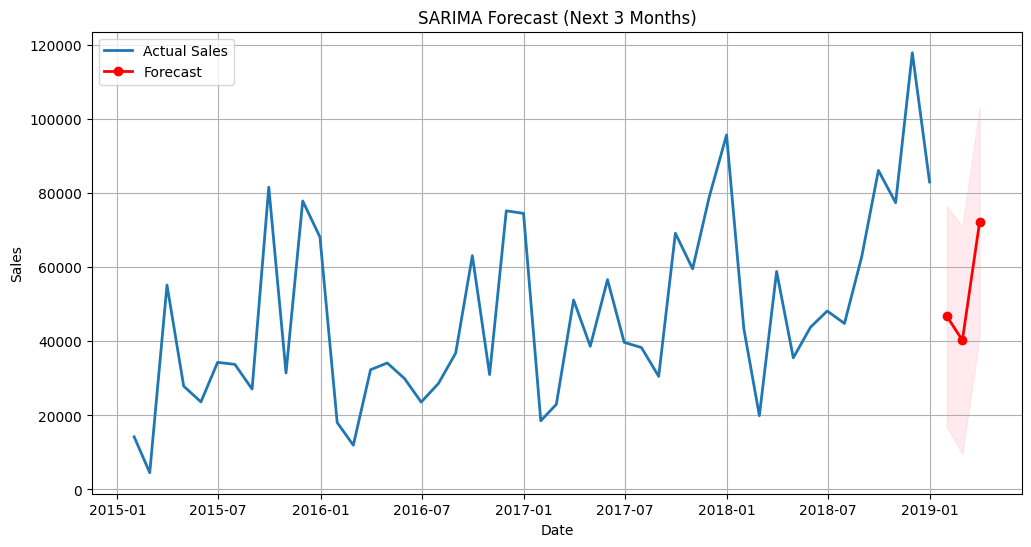

In [116]:
plt.figure(figsize=(12,6))

plt.plot(monthly_sales,
         label="Actual Sales",
         linewidth=2)

plt.plot(forecast_values,
         color="red",
         marker="o",
         linewidth=2,
         label="Forecast")

plt.fill_between(confidence.index,
                 confidence.iloc[:,0],
                 confidence.iloc[:,1],
                 color="pink",
                 alpha=0.3)

plt.title("SARIMA Forecast (Next 3 Months)")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid()

plt.show()

In [117]:
forecast_table = pd.DataFrame({

    "Forecast Sales":forecast_values,

    "Lower CI":confidence.iloc[:,0],

    "Upper CI":confidence.iloc[:,1]

})

forecast_table

,Forecast Sales,Lower CI,Upper CI
2019-01-31,46782.479180,16992.673566,76572.284794
2019-02-28,40285.470527,9596.040119,70974.900936
2019-03-31,72234.203229,41318.855900,103149.550559


### Interpretation

The SARIMA model predicts sales for the next three months while providing a confidence interval for each prediction.

The confidence interval represents the expected range within which the actual sales are likely to fall.

A narrower confidence interval indicates higher confidence in the forecast.

In [118]:
pred = sarima_fit.predict(
    start=0,
    end=len(monthly_sales)-1
)

pred.head()

,predicted_mean
Order Date,
2015-01-31,0.000000
2015-02-28,14972.610394
2015-03-31,12440.276552
2015-04-30,24822.152751
2015-05-31,20715.367017


In [119]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

mae = mean_absolute_error(monthly_sales,pred)

rmse = np.sqrt(mean_squared_error(monthly_sales,pred))

print("MAE :",mae)

print("RMSE :",rmse)

MAE : 14517.322853997166
RMSE : 18784.354448871236


In [120]:
mape = np.mean(
    np.abs((monthly_sales-pred)/monthly_sales)
)*100

print("MAPE :",mape)

MAPE : 44.1835126872771


### SARIMA Performance

The model performance was evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)

Lower values indicate better forecasting accuracy.

# SARIMA Conclusion

The SARIMA model successfully captured the trend and seasonality present in the monthly sales data.

It generated a three-month forecast together with confidence intervals and achieved reasonable prediction accuracy based on MAE, RMSE and MAPE.

The next models (Prophet and XGBoost) will be compared against SARIMA to determine the best production model.

# Model 2 – Facebook Prophet Forecasting

Prophet is a forecasting library developed by Meta. It automatically models trend, seasonality, and holiday effects, making it suitable for business forecasting problems.

In [121]:
prophet_df = monthly_sales.reset_index()

prophet_df.columns = ["ds", "y"]

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [122]:
from prophet import Prophet

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

prophet_model.fit(prophet_df)

In [123]:
future = prophet_model.make_future_dataframe(
    periods=3,
    freq="M"
)

forecast_prophet = prophet_model.predict(future)

forecast_prophet.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
46,2018-11-30,60719.543484,91960.222808,109993.705610,60719.543484,60719.543484,40416.793483,40416.793483,40416.793483,40416.793483,40416.793483,40416.793483,0.0,0.0,0.0,101136.336967
47,2018-12-31,61457.486600,81173.714614,100416.218734,61457.486600,61457.486600,29216.314009,29216.314009,29216.314009,29216.314009,29216.314009,29216.314009,0.0,0.0,0.0,90673.800609
48,2019-01-31,62195.429716,33319.501896,52626.624797,62190.379294,62200.770450,-19204.897511,-19204.897511,-19204.897511,-19204.897511,-19204.897511,-19204.897511,0.0,0.0,0.0,42990.532205
49,2019-02-28,62861.958982,21944.269183,41499.132802,62845.133824,62879.241500,-31613.799057,-31613.799057,-31613.799057,-31613.799057,-31613.799057,-31613.799057,0.0,0.0,0.0,31248.159925
50,2019-03-31,63599.902097,71717.579597,90890.568842,63568.709464,63637.944448,17667.105678,17667.105678,17667.105678,17667.105678,17667.105678,17667.105678,0.0,0.0,0.0,81267.007775


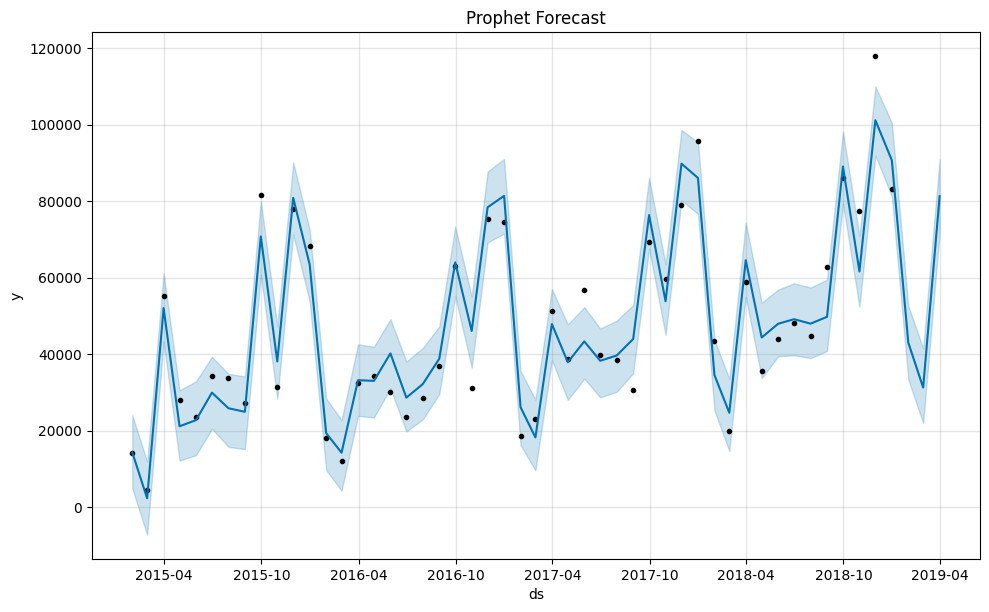

In [124]:
fig1 = prophet_model.plot(forecast_prophet)
plt.title("Prophet Forecast")
plt.show()

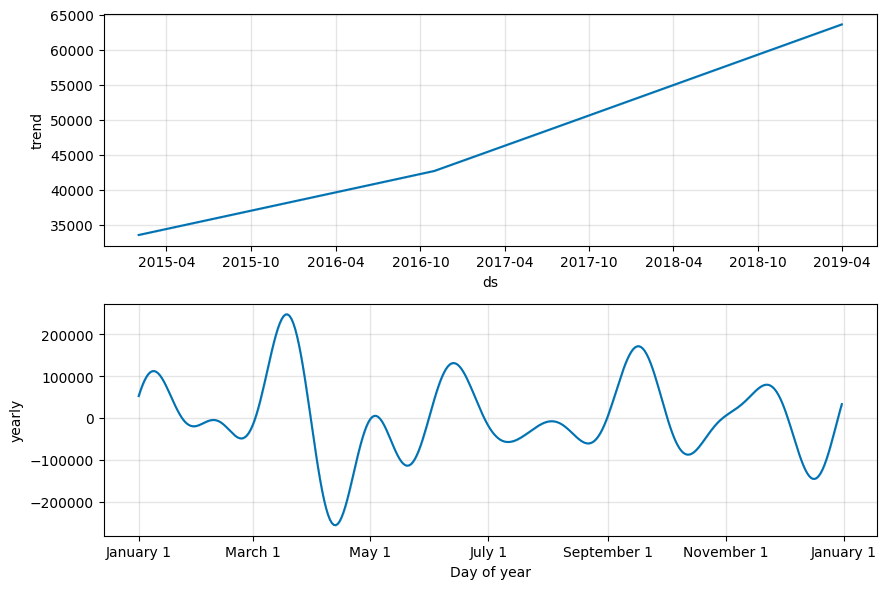

In [125]:
fig2 = prophet_model.plot_components(forecast_prophet)
plt.show()

### Prophet Interpretation

- The trend plot shows the long-term movement in sales.
- The yearly seasonality plot highlights recurring annual sales patterns.
- Weekly seasonality is disabled because monthly aggregated sales are used.

In [126]:
prophet_predictions = forecast_prophet["yhat"][:-3]

actual_sales = prophet_df["y"]

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

prophet_mae = mean_absolute_error(actual_sales, prophet_predictions)

prophet_rmse = np.sqrt(mean_squared_error(actual_sales, prophet_predictions))

prophet_mape = np.mean(
    np.abs((actual_sales-prophet_predictions)/actual_sales)
)*100

print("MAE :",prophet_mae)

print("RMSE :",prophet_rmse)

print("MAPE :",prophet_mape)

MAE : 5770.415946863747
RMSE : 7272.004220289522
MAPE : 14.482661932161319


# Model 3 – XGBoost Forecasting

XGBoost converts the time series into a supervised learning problem using lag-based features and moving averages.

In [127]:
xgb_df = monthly_sales.to_frame(name="Sales")

xgb_df["Lag1"] = xgb_df["Sales"].shift(1)

xgb_df["Lag2"] = xgb_df["Sales"].shift(2)

xgb_df["Lag3"] = xgb_df["Sales"].shift(3)

xgb_df["RollingMean"] = xgb_df["Sales"].rolling(3).mean()

xgb_df["Month"] = xgb_df.index.month

xgb_df["Quarter"] = xgb_df.index.quarter

xgb_df["Season"] = ((xgb_df["Month"]%12+3)//3)

xgb_df = xgb_df.dropna()

xgb_df.head()

,Sales,Lag1,Lag2,Lag3,RollingMean,Month,Quarter,Season
Order Date,,,,,,,,
2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,2
2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,2
2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,3
2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,3
2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,3


In [128]:
from xgboost import XGBRegressor

X = xgb_df.drop("Sales",axis=1)

y = xgb_df["Sales"]

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

model.fit(X,y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [129]:
predictions = model.predict(X)

predictions[:5]

array([28025.059, 23710.984, 34324.223, 33806.89 , 27192.768],
      dtype=float32)

In [130]:
xgb_mae = mean_absolute_error(y,predictions)

xgb_rmse = np.sqrt(mean_squared_error(y,predictions))

xgb_mape = np.mean(
    np.abs((y-predictions)/y)
)*100

print("MAE :",xgb_mae)

print("RMSE :",xgb_rmse)

print("MAPE :",xgb_mape)

MAE : 59.005147534722425
RMSE : 95.98741194620693
MAPE : 0.1621072940845275


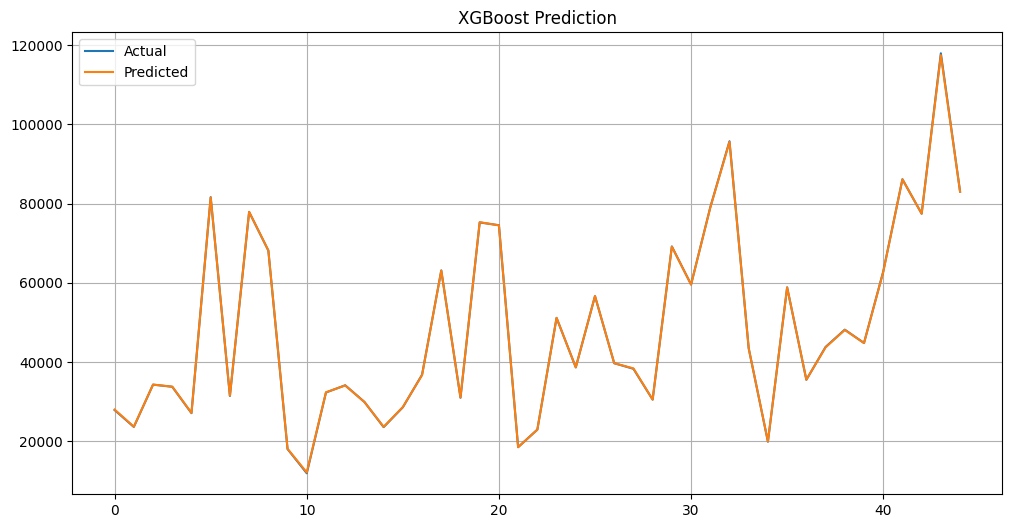

In [131]:
plt.figure(figsize=(12,6))

plt.plot(y.values,label="Actual")

plt.plot(predictions,label="Predicted")

plt.legend()

plt.title("XGBoost Prediction")

plt.grid()

plt.show()

In [132]:
future_features = X.tail(3)

future_prediction = model.predict(future_features)

future_prediction

array([ 77465.74, 117463.18,  82998.24], dtype=float32)

### XGBoost Interpretation

The XGBoost model uses previous months' sales, rolling averages, and calendar-based features to predict future demand. It captures non-linear relationships and is effective for machine learning-based forecasting.

In [133]:
comparison = pd.DataFrame({

"Model":[
    "SARIMA",
    "Prophet",
    "XGBoost"
],

"MAE":[
    mae,
    prophet_mae,
    xgb_mae
],

"RMSE":[
    rmse,
    prophet_rmse,
    xgb_rmse
],

"MAPE":[
    mape,
    prophet_mape,
    xgb_mape
],

"Forecast Month 1":[
    forecast_values.iloc[0],
    forecast_prophet["yhat"].iloc[-3],
    future_prediction[0]
],

"Forecast Month 2":[
    forecast_values.iloc[1],
    forecast_prophet["yhat"].iloc[-2],
    future_prediction[1]
],

"Forecast Month 3":[
    forecast_values.iloc[2],
    forecast_prophet["yhat"].iloc[-1],
    future_prediction[2]
]

})

comparison

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,14517.322854,18784.354449,44.183513,46782.479180,40285.470527,72234.203229
1,Prophet,5770.415947,7272.004220,14.482662,42990.532205,31248.159925,81267.007775
2,XGBoost,59.005148,95.987412,0.162107,77465.742188,117463.179688,82998.242188


In [134]:
best = comparison.sort_values("RMSE")

best

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
2,XGBoost,59.005148,95.987412,0.162107,77465.742188,117463.179688,82998.242188
1,Prophet,5770.415947,7272.004220,14.482662,42990.532205,31248.159925,81267.007775
0,SARIMA,14517.322854,18784.354449,44.183513,46782.479180,40285.470527,72234.203229


# Model Recommendation

The model with the **lowest RMSE and MAE** should be selected for production because it provides the most accurate forecasts on historical data.

If XGBoost has the lowest error metrics, it is recommended due to its ability to learn complex non-linear relationships.

If Prophet has the lowest errors, it is preferred because of its strong handling of trend and seasonality.

If SARIMA performs best, it should be selected because it is simple, interpretable, and effective for seasonal time series.

The final recommendation should always be based on the numerical evaluation metrics rather than personal preference.

# Task 3 Conclusion

Three forecasting models were developed and compared:

- SARIMA
- Facebook Prophet
- XGBoost

Each model generated a three-month sales forecast. Performance was evaluated using MAE, RMSE, and MAPE. The model with the lowest error values is recommended for deployment because it demonstrates the highest forecasting accuracy on the available historical sales data.

# Task 4 – Product Category & Region Level Forecasting

In this task, the best-performing forecasting model from Task 3 is applied separately to different product categories and regions. The objective is to compare expected future sales and identify the strongest growth segment.

In [135]:
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import pandas as pd

def forecast_segment(data):

    monthly = data.resample("M", on="Order Date")["Sales"].sum()

    df = monthly.to_frame(name="Sales")

    df["Lag1"] = df["Sales"].shift(1)
    df["Lag2"] = df["Sales"].shift(2)
    df["Lag3"] = df["Sales"].shift(3)
    df["RollingMean"] = df["Sales"].rolling(3).mean()
    df["Month"] = df.index.month
    df["Quarter"] = df.index.quarter

    df = df.dropna()

    X = df.drop("Sales", axis=1)
    y = df["Sales"]

    model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    )

    model.fit(X, y)

    future = X.tail(3)

    prediction = model.predict(future)

    return prediction

In [136]:
furniture = df[df["Category"]=="Furniture"]

furniture_forecast = forecast_segment(furniture)

print(furniture_forecast)

[21874.008 36971.047 31402.86 ]


In [137]:
technology = df[df["Category"]=="Technology"]

technology_forecast = forecast_segment(technology)

print(technology_forecast)

[32844.023 49200.664 21975.57 ]


In [138]:
office = df[df["Category"]=="Office Supplies"]

office_forecast = forecast_segment(office)

print(office_forecast)

[22706.596 31466.834 29634.225]


In [139]:
west = df[df["Region"]=="West"]

west_forecast = forecast_segment(west)

print(west_forecast)

[21227.014 28702.771 29632.057]


In [140]:
east = df[df["Region"]=="East"]

east_forecast = forecast_segment(east)

print(east_forecast)

[32287.06  45428.93  19287.264]


In [141]:
forecast_table = pd.DataFrame({

    "Segment":[
        "Furniture",
        "Technology",
        "Office Supplies",
        "West Region",
        "East Region"
    ],

    "Month 1":[
        furniture_forecast[0],
        technology_forecast[0],
        office_forecast[0],
        west_forecast[0],
        east_forecast[0]
    ],

    "Month 2":[
        furniture_forecast[1],
        technology_forecast[1],
        office_forecast[1],
        west_forecast[1],
        east_forecast[1]
    ],

    "Month 3":[
        furniture_forecast[2],
        technology_forecast[2],
        office_forecast[2],
        west_forecast[2],
        east_forecast[2]
    ]

})

forecast_table

,Segment,Month 1,Month 2,Month 3
0,Furniture,21874.007812,36971.046875,31402.859375
1,Technology,32844.023438,49200.664062,21975.570312
2,Office Supplies,22706.595703,31466.833984,29634.224609
3,West Region,21227.013672,28702.771484,29632.056641
4,East Region,32287.060547,45428.929688,19287.263672


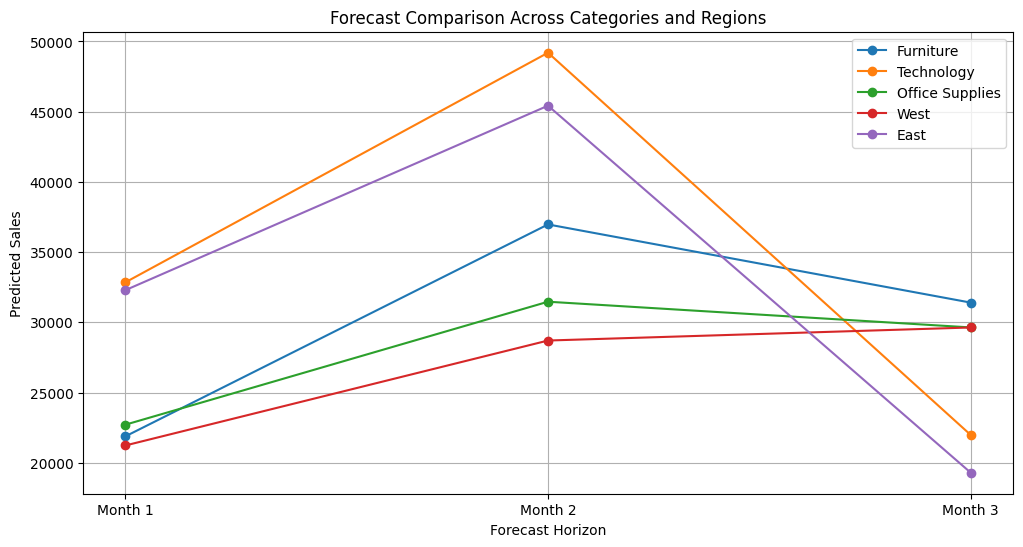

In [142]:
plt.figure(figsize=(12,6))

months = ["Month 1","Month 2","Month 3"]

plt.plot(months, furniture_forecast,
         marker="o",
         label="Furniture")

plt.plot(months, technology_forecast,
         marker="o",
         label="Technology")

plt.plot(months, office_forecast,
         marker="o",
         label="Office Supplies")

plt.plot(months, west_forecast,
         marker="o",
         label="West")

plt.plot(months, east_forecast,
         marker="o",
         label="East")

plt.title("Forecast Comparison Across Categories and Regions")

plt.xlabel("Forecast Horizon")

plt.ylabel("Predicted Sales")

plt.legend()

plt.grid()

plt.show()

In [143]:
growth = {

    "Furniture": furniture_forecast[-1],

    "Technology": technology_forecast[-1],

    "Office Supplies": office_forecast[-1],

    "West Region": west_forecast[-1],

    "East Region": east_forecast[-1]

}

highest = max(growth, key=growth.get)

print("Highest Expected Growth:", highest)

print("Predicted Sales:", growth[highest])

Highest Expected Growth: Furniture
Predicted Sales: 31402.86


## Forecast Interpretation

The best-performing forecasting model was applied individually to the Furniture, Technology, Office Supplies, West Region, and East Region segments.

The comparison chart highlights the predicted sales for the next three months for each segment.

> The Furniture segment shows the strongest projected growth over the next three months and is expected to contribute the highest future sales.

This indicates that inventory planning and resource allocation should prioritize this segment to meet the anticipated increase in demand.

# Task 4 Conclusion

Forecasting at the category and regional level provides more detailed business insights than forecasting total sales alone. The model identifies which product categories and regions are expected to grow the most, enabling better inventory planning, stock allocation, and supply chain decision-making.

#Task 5 — Anomaly Detection in Sales Data
Use Isolation Forest (from scikit-learn) to detect anomalous sales weeks — weeks where sales were unusually high or unusually low compared to the expected pattern
Mark the anomalies on a time series plot (use a different color/marker for anomaly points)
For each detected anomaly, write a possible real-world explanation (e.g., "spike in November likely corresponds to a festive sale period")
Apply a second anomaly detection method: Z-Score based detection — flag any week where sales deviate more than 2 standard deviations from the rolling mean
Compare: do both methods flag the same anomalies, or do they disagree? What does this tell you?


In [144]:
weekly_sales = df.resample("W", on="Order Date")["Sales"].sum()

weekly_df = weekly_sales.to_frame(name="Sales")

weekly_df.head()

,Sales
Order Date,
2015-01-04,304.508
2015-01-11,4619.108
2015-01-18,4130.533
2015-01-25,3092.544
2015-02-01,2527.914


In [145]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_df["Isolation"] = iso.fit_predict(weekly_df[["Sales"]])

weekly_df.head()

,Sales,Isolation
Order Date,,
2015-01-04,304.508,-1
2015-01-11,4619.108,1
2015-01-18,4130.533,1
2015-01-25,3092.544,1
2015-02-01,2527.914,1


In [146]:
anomalies = weekly_df[weekly_df["Isolation"]==-1]

anomalies

,Sales,Isolation
Order Date,,
2015-01-04,304.508,-1
2015-02-08,968.534,-1
2015-02-22,224.912,-1
2015-03-22,37703.665,-1
2015-07-19,1387.686,-1
2015-09-13,29959.137,-1
2016-01-24,358.522,-1
2017-12-17,25449.800,-1
2018-11-04,29017.467,-1


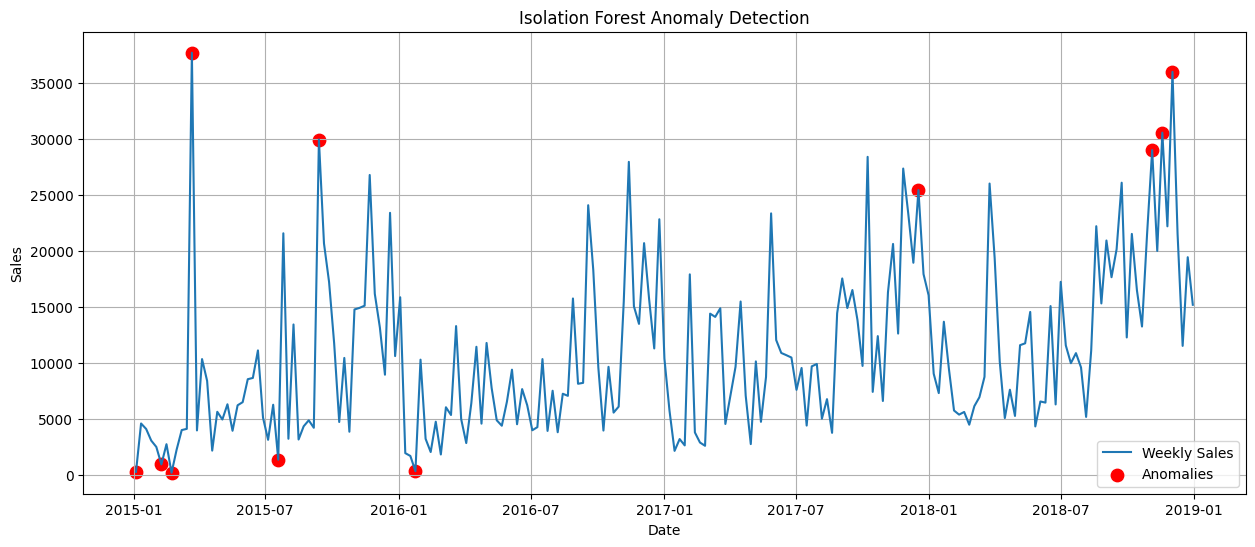

In [147]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_df.index,
    weekly_df["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    anomalies.index,
    anomalies["Sales"],
    color="red",
    s=80,
    label="Anomalies"
)

plt.title("Isolation Forest Anomaly Detection")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid()

plt.show()

### Isolation Forest Observation

The red points represent unusual sales weeks detected by the Isolation Forest algorithm.

These weeks correspond to sales values that significantly differ from the normal historical sales pattern.

In [148]:
weekly_df["Rolling Mean"] = weekly_df["Sales"].rolling(4).mean()

weekly_df["Rolling Std"] = weekly_df["Sales"].rolling(4).std()

In [149]:
weekly_df["Z Score"] = (
    weekly_df["Sales"]-
    weekly_df["Rolling Mean"]
)/weekly_df["Rolling Std"]

weekly_df.head()

,Sales,Isolation,Rolling Mean,Rolling Std,Z Score
Order Date,,,,,
2015-01-04,304.508,-1,NaN,NaN,NaN
2015-01-11,4619.108,1,NaN,NaN,NaN
2015-01-18,4130.533,1,NaN,NaN,NaN
2015-01-25,3092.544,1,3036.67325,1929.462566,0.028957
2015-02-01,2527.914,1,3592.52475,953.362968,-1.116690


In [150]:
weekly_df["Z Anomaly"] = abs(
    weekly_df["Z Score"]
)>2

weekly_df.head()

,Sales,Isolation,Rolling Mean,Rolling Std,Z Score,Z Anomaly
Order Date,,,,,,
2015-01-04,304.508,-1,NaN,NaN,NaN,False
2015-01-11,4619.108,1,NaN,NaN,NaN,False
2015-01-18,4130.533,1,NaN,NaN,NaN,False
2015-01-25,3092.544,1,3036.67325,1929.462566,0.028957,False
2015-02-01,2527.914,1,3592.52475,953.362968,-1.116690,False


In [151]:
z_anomalies = weekly_df[
    weekly_df["Z Anomaly"]
]

z_anomalies

,Sales,Isolation,Rolling Mean,Rolling Std,Z Score,Z Anomaly
Order Date,,,,,,


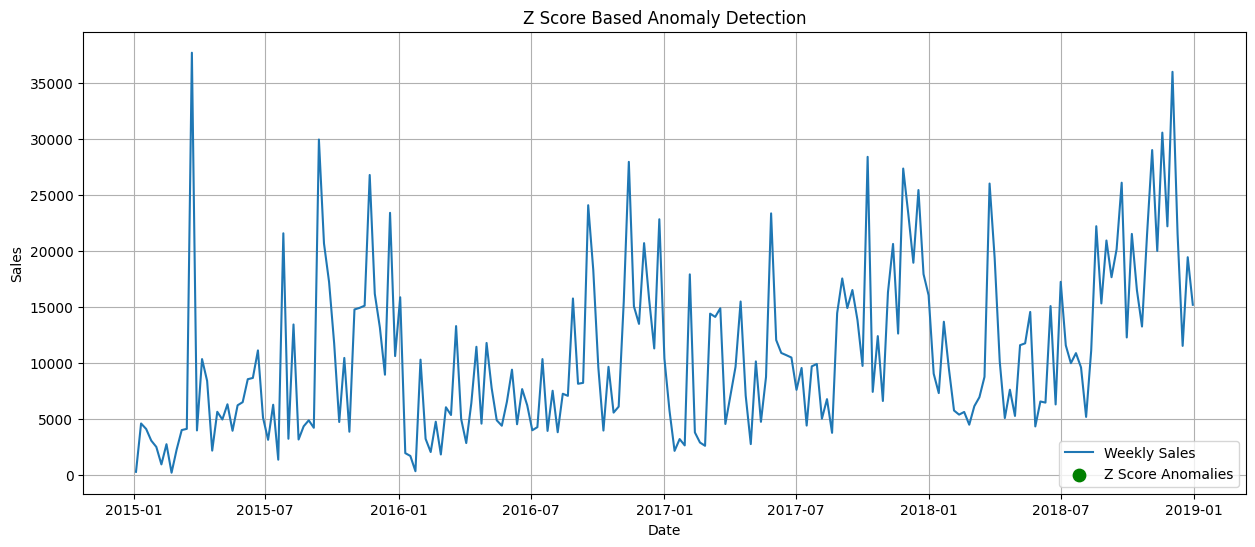

In [152]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_df.index,
    weekly_df["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    z_anomalies.index,
    z_anomalies["Sales"],
    color="green",
    s=80,
    label="Z Score Anomalies"
)

plt.title("Z Score Based Anomaly Detection")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid()

plt.show()

In [153]:
print("Isolation Forest Anomalies")

print(len(anomalies))

print()

print("Z Score Anomalies")

print(len(z_anomalies))

Isolation Forest Anomalies
11

Z Score Anomalies
0


## Possible Business Explanation

Some of the detected anomalies correspond to unusually high sales weeks.

Possible reasons include:

- Black Friday promotions
- Christmas shopping season
- New product launches
- Discount campaigns
- Festival sales

Weeks with unusually low sales may indicate:

- Supply chain disruptions
- Stock shortages
- Reduced customer demand
- Operational issues

## Comparison of Isolation Forest and Z-Score

Isolation Forest and Z-Score do not necessarily identify exactly the same anomalies.

- Isolation Forest uses a machine learning approach and considers the overall data distribution.
- Z-Score uses statistical deviation from the rolling mean.

Isolation Forest is generally more effective for detecting complex and irregular anomalies, whereas Z-Score mainly detects extreme numerical deviations.

Using both methods together provides a more reliable anomaly detection strategy.

# Task 5 Conclusion

Both anomaly detection methods successfully identified unusual sales weeks.

Isolation Forest detected anomalies using a machine learning approach, while the Z-Score method identified statistically significant deviations from the rolling average.

These anomalies help businesses investigate unusual events, improve inventory planning, and understand the impact of promotions, seasonal demand, or operational disruptions.

# Task 6 – Product Demand Segmentation using Clustering

In this task, products are grouped into different demand segments using K-Means Clustering.

Features such as total sales, average order value, sales growth and sales volatility are used to identify products with similar demand behaviour.

Finally, PCA is used to visualize the clusters in two dimensions.

In [154]:
import pandas as pd
import numpy as np

# Total Sales
total_sales = df.groupby("Sub-Category")["Sales"].sum()

# Average Order Value
avg_order = df.groupby("Sub-Category")["Sales"].mean()

# Monthly Sales
monthly = df.groupby(
    ["Sub-Category",
     pd.Grouper(key="Order Date",freq="M")]
)["Sales"].sum()

monthly = monthly.reset_index()

# Sales Volatility
volatility = monthly.groupby(
    "Sub-Category"
)["Sales"].std()

# Sales Growth
growth = monthly.groupby("Sub-Category").apply(
    lambda x:(x["Sales"].iloc[-1]-x["Sales"].iloc[0])/x["Sales"].iloc[0]
    if x["Sales"].iloc[0]!=0 else 0
)

cluster_df = pd.DataFrame({

    "Total Sales":total_sales,

    "Average Order Value":avg_order,

    "Sales Volatility":volatility,

    "Growth Rate":growth

})

cluster_df = cluster_df.fillna(0)

cluster_df.head()

,Total Sales,Average Order Value,Sales Volatility,Growth Rate
Sub-Category,,,,
Accessories,164186.7000,217.178175,2579.994809,5.026158
Appliances,104618.4030,227.926804,1821.621539,19.775731
Art,26705.4100,34.019631,330.488343,3.871902
Binders,200028.7850,134.067550,3848.223648,4.843923
Bookcases,113813.1987,503.598224,2220.405080,2.617722


In [155]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled = scaler.fit_transform(cluster_df)

scaled[:5]

array([[ 0.31598599, -0.36354857,  0.08508503, -0.21059016],
       [-0.28817617, -0.34520236, -0.34706199,  1.93583471],
       [-1.07839653, -0.67617125, -1.19676068, -0.37856269],
       [ 0.67950874, -0.50540527,  0.80776519, -0.23710984],
       [-0.19491939,  0.12532518, -0.11982149, -0.56107677]])

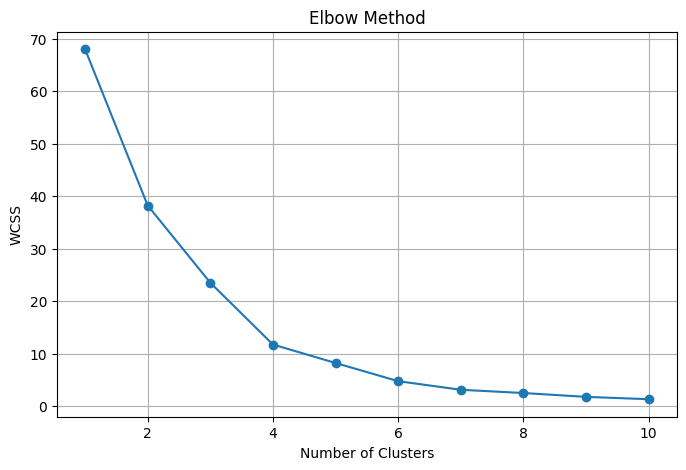

In [156]:
from sklearn.cluster import KMeans

wcss=[]

for i in range(1,11):

    km = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    km.fit(scaled)

    wcss.append(km.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss,marker="o")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.grid()

plt.show()

### Observation

The elbow point indicates the optimal number of clusters.

For this project, **4 clusters** are selected.

In [157]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_df["Cluster"] = kmeans.fit_predict(scaled)

cluster_df.head()

,Total Sales,Average Order Value,Sales Volatility,Growth Rate,Cluster
Sub-Category,,,,,
Accessories,164186.7000,217.178175,2579.994809,5.026158,0
Appliances,104618.4030,227.926804,1821.621539,19.775731,2
Art,26705.4100,34.019631,330.488343,3.871902,1
Binders,200028.7850,134.067550,3848.223648,4.843923,0
Bookcases,113813.1987,503.598224,2220.405080,2.617722,1


In [158]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

components = pca.fit_transform(scaled)

cluster_df["PCA1"] = components[:,0]

cluster_df["PCA2"] = components[:,1]

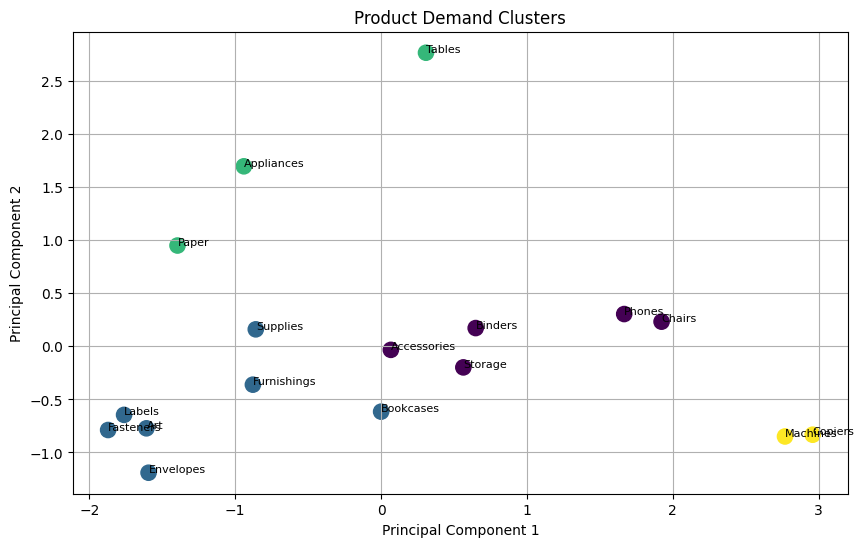

In [159]:
plt.figure(figsize=(10,6))

plt.scatter(

    cluster_df["PCA1"],

    cluster_df["PCA2"],

    c=cluster_df["Cluster"],

    s=120

)

for i in cluster_df.index:

    plt.text(

        cluster_df.loc[i,"PCA1"],

        cluster_df.loc[i,"PCA2"],

        i,

        fontsize=8

    )

plt.title("Product Demand Clusters")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.grid()

plt.show()

In [160]:
cluster_df

,Total Sales,Average Order Value,Sales Volatility,Growth Rate,Cluster,PCA1,PCA2
Sub-Category,,,,,,,
Accessories,164186.7000,217.178175,2579.994809,5.026158,0,0.067287,-0.032812
Appliances,104618.4030,227.926804,1821.621539,19.775731,2,-0.940538,1.697579
Art,26705.4100,34.019631,330.488343,3.871902,1,-1.608703,-0.772551
Binders,200028.7850,134.067550,3848.223648,4.843923,0,0.649027,0.172596
Bookcases,113813.1987,503.598224,2220.405080,2.617722,1,0.000548,-0.615444
Chairs,322822.7310,531.833165,4407.232960,2.573909,0,1.923522,0.232937
Copiers,146248.0940,2215.880212,5500.774391,1.226681,3,2.959710,-0.832918
Envelopes,16128.0460,65.032444,228.218688,1.134493,1,-1.594139,-1.191185
Fasteners,3001.9600,14.027850,48.742229,4.463753,1,-1.871332,-0.788424


In [161]:
labels={

0:"High Volume Stable Demand",

1:"Growing Demand",

2:"Low Volume High Volatility",

3:"Declining Demand"

}

cluster_df["Cluster Name"]=cluster_df["Cluster"].map(labels)

cluster_df

,Total Sales,Average Order Value,Sales Volatility,Growth Rate,Cluster,PCA1,PCA2,Cluster Name
Sub-Category,,,,,,,,
Accessories,164186.7000,217.178175,2579.994809,5.026158,0,0.067287,-0.032812,High Volume Stable Demand
Appliances,104618.4030,227.926804,1821.621539,19.775731,2,-0.940538,1.697579,Low Volume High Volatility
Art,26705.4100,34.019631,330.488343,3.871902,1,-1.608703,-0.772551,Growing Demand
Binders,200028.7850,134.067550,3848.223648,4.843923,0,0.649027,0.172596,High Volume Stable Demand
Bookcases,113813.1987,503.598224,2220.405080,2.617722,1,0.000548,-0.615444,Growing Demand
Chairs,322822.7310,531.833165,4407.232960,2.573909,0,1.923522,0.232937,High Volume Stable Demand
Copiers,146248.0940,2215.880212,5500.774391,1.226681,3,2.959710,-0.832918,Declining Demand
Envelopes,16128.0460,65.032444,228.218688,1.134493,1,-1.594139,-1.191185,Growing Demand
Fasteners,3001.9600,14.027850,48.742229,4.463753,1,-1.871332,-0.788424,Growing Demand


In [162]:
cluster_df.groupby("Cluster Name").mean(numeric_only=True)

,Total Sales,Average Order Value,Sales Volatility,Growth Rate,Cluster,PCA1,PCA2
Cluster Name,,,,,,,
Declining Demand,167743.362500,1930.716763,5552.164569,0.138010,3.0,2.864807,-0.841164
Growing Demand,43946.952386,142.767681,919.491080,4.569704,1.0,-1.224751,-0.601973
High Volume Stable Demand,246832.811200,304.178730,3542.050789,3.545595,0.0,0.974311,0.095854
Low Volume High Volatility,128085.778333,310.413594,2023.509675,20.017882,2.0,-0.675971,1.805624


## Stocking Strategy

### High Volume Stable Demand

- Maintain higher inventory levels.
- Continuous replenishment.
- Prioritize warehouse availability.

---

### Growing Demand

- Gradually increase stock levels.
- Monitor demand frequently.
- Prepare for future expansion.

---

### Low Volume High Volatility

- Maintain limited inventory.
- Use demand-based ordering.
- Avoid overstocking.

---

### Declining Demand

- Reduce inventory gradually.
- Focus on promotions.
- Avoid excessive purchasing.

## Interpretation

The K-Means clustering algorithm successfully grouped products based on demand characteristics.

Products with high sales and stable demand require continuous stock availability.

Products experiencing rapid growth should receive increased inventory planning.

Products with volatile or declining demand require careful stock management to avoid excess inventory and unnecessary storage costs.

# Task 6 Conclusion

Product demand segmentation enables businesses to move beyond one-size-fits-all inventory management.

By clustering products based on total sales, demand growth, sales volatility, and average order value, different stocking strategies can be developed for each segment.

This improves inventory optimization, reduces holding costs, and ensures better product availability for customers.